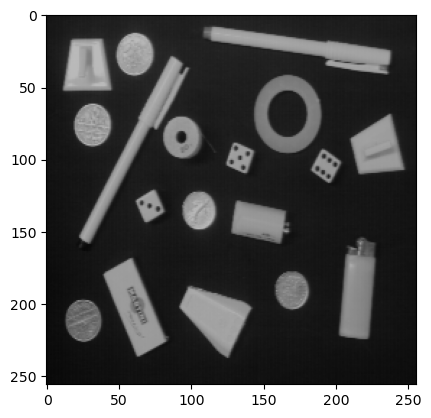

In [29]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("images/objects.png", cv2.IMREAD_GRAYSCALE)

image = image.astype(np.uint32)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()


Operador de Sobel

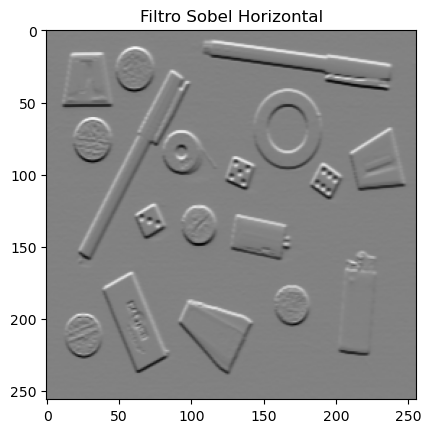

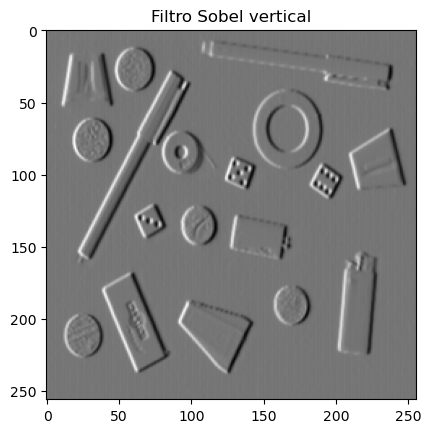

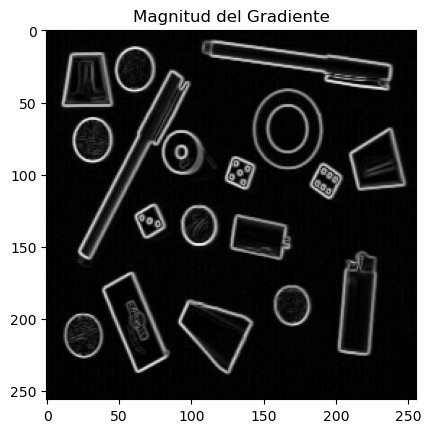

In [30]:
# Aplique un filtro de Sobel horizontal sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

from skimage.filters import sobel_h, sobel_v, sobel

#Aplica el filtro Sobel horizontal
img_sh = sobel_h(image)
# Visualizar imagen
plt.imshow(img_sh, cmap="gray")
plt.title("Filtro Sobel Horizontal")
plt.show()

#--- Aplique un filtro de Sobel vertical sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.
#Aplica el filtro Sobel vertical
img_sv = sobel_v(image)
# Visualizar imagen
plt.imshow(img_sv, cmap="gray")
plt.title("Filtro Sobel vertical")
plt.show()

# Calcule la norma (magnitud) del gradiente de acuerdo con la definición a partir de las dos imágenes resultantes anteriores. Visualice los resultados.
# Magnitud del gradiente
gradiente_sobel = np.sqrt(img_sh**2 + img_sv**2)

# Visualizar
plt.imshow(gradiente_sobel, cmap="gray")
plt.title("Magnitud del Gradiente")
plt.show()

Describa cualitativamente cada una de estas tres imágenes: imagen del gradiente en X, imagen del gradiente en Y e imagen de la norma del gradiente.

La imagen del gradiente en X, encuentra contornos que van en direccion del eje horizontal, por ejemplo la parte de abajo de los borradores, la parte de abajo de los esferos, dados se resalta una sombra. En cambio, con la imagen del gradiente en Y, se resaltan los bordes que van en direccion del eje vertical, ya no se resaltan las partes de abajo de los borradores, ahora se resaltan los bordes laterales, tambien es muy notorio en los esferos, la sombra resaltada va en la misma direccion del eje. Con respecto a la imagen de la norma del gradiente, ya es la imagen a la que esperabamos llegar, aqui se resaltan todos los bordes de los objetos, dejando muy claro en que parte de la imagen se encuentran estos picos o saltos de gris.

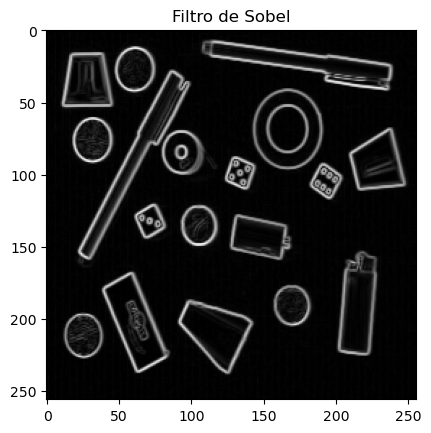

In [31]:
#Aplique un filtro de Sobel sobre la imagen y visualice los resultados. Compare la imagen con la obtenido en el punto anterior.
#Calcula bordes usando el filtro de sobel
img_s = sobel(image)
# Visualizar imagen
plt.imshow(img_s, cmap="gray")
plt.title("Filtro de Sobel")
plt.show()



Operador de Prewitt

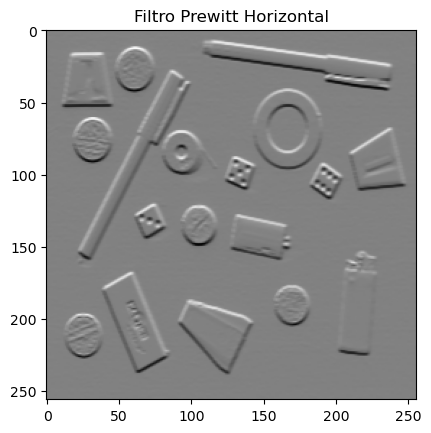

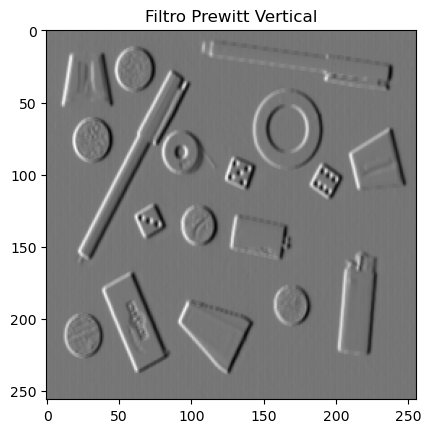

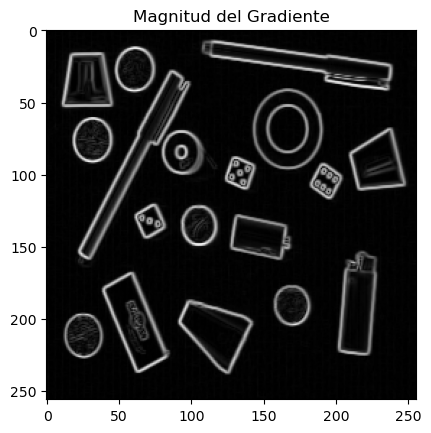

In [32]:
#Aplique un filtro de Prewitt horizontal sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

from skimage.filters import prewitt_h, prewitt_v, prewitt

#Aplica el filtro Prewitt horizontal
img_ph = prewitt_h(image)
# Visualizar imagen
plt.imshow(img_ph, cmap="gray")
plt.title("Filtro Prewitt Horizontal")
plt.show()

#-----Aplique un filtro de Prewitt vertical sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.
#Aplica el filtro Prewitt vertical
img_pv = prewitt_v(image)
# Visualizar imagen
plt.imshow(img_pv, cmap="gray")
plt.title("Filtro Prewitt Vertical")
plt.show()

#---Calcule la norma (magnitud) del gradiente de acuerdo con la definición a partir de las dos imágenes resultantes anteriores. Visualice los resultados.
# Magnitud del gradiente
gradiente_prewitt = np.sqrt(img_ph**2 + img_pv**2)
# Visualizar
plt.imshow(gradiente_prewitt, cmap="gray")
plt.title("Magnitud del Gradiente")
plt.show()


Describa cualitativamente cada una de estas tres imágenes: imagen del gradiente en X, imagen del gradiente en Y e imagen de la norma del gradiente.
La imagen del gradiente en X, encuentra contornos que van en direccion del eje x, por ejemplo la parte de abajo de los borradores, la parte de abajo de los esferos, dados se resalta una sombra. En cambio, con la imagen del gradiente en Y, se resaltan los bordes que van en direccion de Y, ya no se resaltan las partes de abajo de los borradores, ahora se resaltan los bordes laterales, tambien es muy notorio en los esferos, la sombra resaltada va en la misma direccion de Y. Con respecto a la imagen de la norma del gradiente, ya es la imagen a la que esperabamos llegar, aqui se resaltan todos los bordes de los objetos, dejando muy claro en que parte de la imagen se encuentran estos picos o saltos de gris.

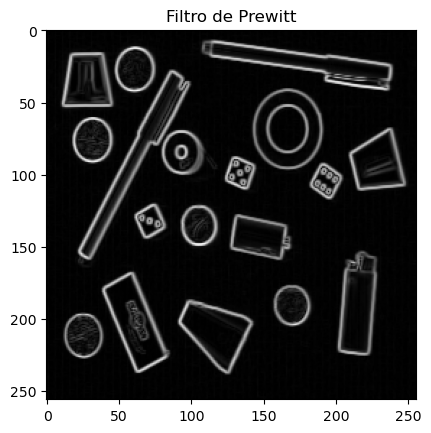

In [33]:
#Aplique un filtro de Prewitt sobre la imagen y visualice los resultados. Compare la imagen con la obtenido en el punto anterior.
#Calcula bordes usando el filtro de sobel
img_p = prewitt(image)

# Visualizar
plt.imshow(img_p, cmap="gray")
plt.title("Filtro de Prewitt")
plt.show()

Diferencia entre Sobel y Prewitt:

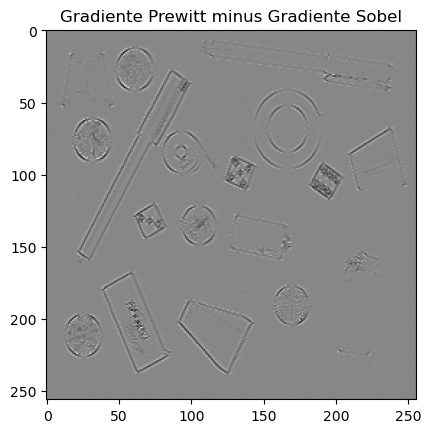

In [36]:
#Sustraiga a la imagen de la norma de Prewitt, la imagen de la norma del gradiente calculada con el operador de Sobel.
subtraction = cv2.subtract(gradiente_prewitt, gradiente_sobel)

# Visualizar
plt.imshow(subtraction, cmap="gray")
plt.title("Gradiente Prewitt minus Gradiente Sobel")
plt.show()

¿Qué diferencia visual hay entre el operador de Sobel y el de Prewitt?

Lo que puedo ver en diferencias, es que los bordes de Sobel son un poco mas definidos, al tener un kernel donde le brinda mas peso al pixel central (porque el 2 esta en el medio) puede llegar a manejar mucho mejor el ruido, por eso suaviza mas la imagen. En comparación con Prewitt, su kernel tiene todos los pesos por igual, aca el ruido puede distorsionar los bordes.



Para explicar esta diferencia, calcule numéricamente las respuestas del cálculo del gradiente en x, en y y de la norma del gradiente de cada uno de los dos filtros en los siguientes casos:

In [ ]:
import numpy as np

# Prewitt
prewitt_gx = np.array([[-1, 0, 1],
                       [-1, 0, 1],
                       [-1, 0, 1]])

prewitt_gy = np.array([[ 1,  1,  1],
                       [ 0,  0,  0],
                       [-1, -1, -1]])

# Sobel
sobel_gx = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])

sobel_gy = np.array([[ 1,  2,  1],
                     [ 0,  0,  0],
                     [-1, -2, -1]])

# =========================
# Casos de prueba
# =========================

cases = {
    "Frontera Horizontal": np.array([
        [0,   0,   0],
        [0,   0,   0],
        [255, 255, 255]
    ]),
    
    "Frontera Vertical": np.array([
        [0, 0, 255],
        [0, 0, 255],
        [0, 0, 255]
    ]),
    
    "Frontera Oblicua": np.array([
        [0,   0,   255],
        [0,   255, 255],
        [255, 255, 255]
    ])
}

case_frontera = {
    "Lejos del Borde": np.array([
        [0, 0, 0, 0],
        [0, 0, 0, 255],
        [0, 0, 255, 255],
        [0, 255, 255, 255]
    ])
}


def compute_gradients(image, gx_kernel, gy_kernel):
    gx = np.sum(image * gx_kernel)
    gy = np.sum(image * gy_kernel)
    magnitude = np.abs(gx) + np.abs(gy)
    return gx, gy, magnitude

for name, img in cases.items():
    print(f"\n===== {name} =====")
    
    # Prewitt
    gx_p, gy_p, mag_p = compute_gradients(img, prewitt_gx, prewitt_gy)
    print("Prewitt -> gx:", gx_p, "gy:", gy_p, "Norma:", mag_p)
    
    # Sobel
    gx_s, gy_s, mag_s = compute_gradients(img, sobel_gx, sobel_gy)
    print("Sobel   -> gx:", gx_s, "gy:", gy_s, "Norma:", mag_s)
    
    

    
# Extraer región centrada en (1,1)
region = np.array([
        [0, 0, 0, 0],
        [0, 0, 0, 255],
        [0, 0, 255, 255],
        [0, 255, 255, 255]
    ])[0:3, 0:3]

print("==== Mascara se aleja de la frontera ====")
print(region)

gx_p, gy_p, mag_p = compute_gradients(region, prewitt_gx, prewitt_gy)
gx_s, gy_s, mag_s = compute_gradients(region, sobel_gx, sobel_gy)

print("\nPrewitt -> gx:", gx_p, "gy:", gy_p, "Norma:", mag_p)
print("Sobel   -> gx:", gx_s, "gy:", gy_s, "Norma:", mag_s)


===== Frontera Horizontal =====
Prewitt -> gx: 0 gy: -765 Norma: 765
Sobel   -> gx: 0 gy: -1020 Norma: 1020

===== Frontera Vertical =====
Prewitt -> gx: 765 gy: 0 Norma: 765
Sobel   -> gx: 1020 gy: 0 Norma: 1020

===== Frontera Oblicua =====
Prewitt -> gx: 510 gy: -510 Norma: 1020
Sobel   -> gx: 765 gy: -765 Norma: 1530
==== Mascara se aleja de la frontera ====
[[  0   0   0]
 [  0   0   0]
 [  0   0 255]]

Prewitt -> gx: 255 gy: -255 Norma: 510
Sobel   -> gx: 255 gy: -255 Norma: 510
